# final_notebook_v2

**Purpose:** Train and evaluate the XGBoost password strength classifier using the re-labeled dataset from `raw_data_transform_v2.ipynb`.

Key differences from `final_notebook.ipynb`:
- Dataset: `rockyou_balanced_pwstrength.csv` (labeled with password-strength library, entropy-density based)
- Class merge cell removed — labels are already 0/1/2 directly
- StandardScaler import removed — XGBoost is scale-invariant
- Inference block corrected — model predicts first, heuristics are narrow overrides only
- TFLite export removed, ONNX export retained

In [62]:
# Cell 1 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [63]:
# Cell 2 — Load dataset
# Update path to match your local directory.
# This file was produced by raw_data_transform_v2.ipynb.
# Labels are already 0=Weak, 1=Medium, 2=Strong — no merging required.

df = pd.read_csv(r'E:\major_project\datasets\rockyou_balanced_pwstrength.csv', encoding='latin-1')

print(f'Loaded {len(df):,} rows')
print()
print('Class distribution:')
labels_map = {0: 'Weak', 1: 'Medium', 2: 'Strong'}
for cls, count in df['strength'].value_counts().sort_index().items():
    print(f'  {cls} ({labels_map[cls]}): {count:,} ({count/len(df)*100:.1f}%)')

Loaded 600,000 rows

Class distribution:
  0 (Weak): 200,000 (33.3%)
  1 (Medium): 200,000 (33.3%)
  2 (Strong): 200,000 (33.3%)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  600000 non-null  object
 1   strength  600000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 9.2+ MB


In [65]:
# Cell 3 — Check for nulls and duplicates

print(f'Null values:\n{df.isnull().sum()}')
print()
print(f'Duplicate passwords: {df.duplicated(subset=["password"]).sum()}')

Null values:
password    0
strength    0
dtype: int64

Duplicate passwords: 0


In [66]:
# Cell 4 — Drop nulls and duplicates if any remain
# Should be zero from the transform notebook, but defensive check.

df.dropna(subset=['password'], inplace=True)
df['password'] = df['password'].astype(str)
df.drop_duplicates(subset=['password'], inplace=True)

print(f'After cleaning: {len(df):,} rows')

After cleaning: 600,000 rows


In [67]:
# Cell 5 — Remove invisible control characters

df = df[~df['password'].str.contains(r'[\x00-\x1F\x7F-\x9F]', na=True, regex=True)]

print(f'After control character removal: {len(df):,} rows')

After control character removal: 599,421 rows


## adding length to the dataset

In [68]:
# Cell 6 — Length filter
# Passwords outside 1-50 characters are excluded.
# This was applied in raw_data_transform_v2 but double-checked here
# in case any edge cases slipped through.

df['password'] = df['password'].str.strip()
df['length'] = df['password'].str.len()
df = df[(df['length'] > 0) & (df['length'] <= 50)]

print(f'After length filter: {len(df):,} rows')
print()
print(f'sample print:\n{df.sample(5)}')
print('Final class distribution after cleaning:')
df['strength'].value_counts().sort_index()

After length filter: 599,298 rows

sample print:
                 password  strength  length
412200  MIS2GRANDESAMIGAS         2      17
269426       CONSENTIDA77         1      12
303997          029851700         1       9
158851          Dolores97         0       9
193121           18118896         0       8
Final class distribution after cleaning:


strength
0    199952
1    199872
2    199474
Name: count, dtype: int64

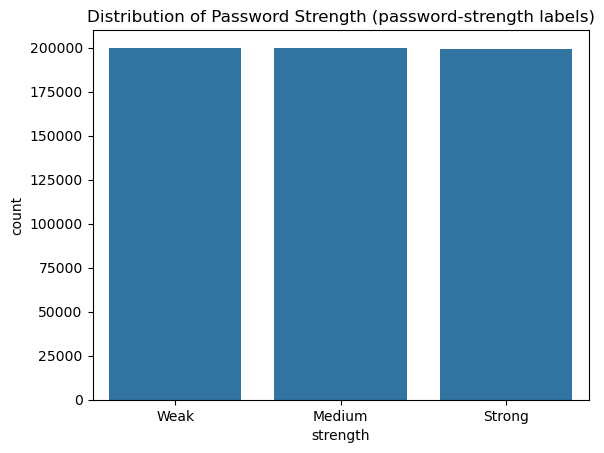

In [69]:
# Cell 7 — Strength distribution plot

sns.countplot(x='strength', data=df)
plt.title('Distribution of Password Strength (password-strength labels)')
plt.xticks([0, 1, 2], ['Weak', 'Medium', 'Strong'])
plt.show()

## Feature Engineering

In [70]:
# Cell 8 — Feature engineering functions
# Identical to final_notebook.ipynb — no changes.

def pass_entropy(x):
    if not x or pd.isna(x): return 0
    freq = pd.Series(list(str(x))).value_counts()
    prob = freq / len(str(x))
    return -np.sum(prob * np.log2(prob))

def max_repeated(x):
    if not x or pd.isna(x): return 0
    return max((len(m.group(0)) for m in re.finditer(r'(.)\1*', str(x))), default=0)

def transitions(x):
    if not x or pd.isna(x): return 0
    x = str(x)
    def char_type(c):
        if c.islower(): return "l"
        if c.isupper(): return "u"
        if c.isdigit(): return "d"
        return "s"
    return sum(char_type(x[i]) != char_type(x[i+1]) for i in range(len(x)-1))

def check_common_root(x):
    common_roots = ['password', 'qwerty', 'admin', 'welcome', 'login', 'google', 'iloveyou', 'p@ss', 'pass', 'monkey', 'dragon']
    x_lower = str(x).lower()
    return 1 if any(root in x_lower for root in common_roots) else 0

def leet_count(x):
    return sum(c in "@$!013457" for c in str(x))

def shape_score(x):
    if not x or pd.isna(x): return 0
    shape = ""
    for char in str(x):
        if char.isupper(): shape += "U"
        elif char.islower(): shape += "L"
        elif char.isdigit(): shape += "D"
        else: shape += "S"
    chunks = set([shape[i:i+2] for i in range(len(shape)-1)])
    return len(chunks)

def get_pattern_score(x):
    x_lower = str(x).lower()
    score = 0
    sequences = ['abcdefghijklmnopqrstuvwxyz', '0123456789', 'qwertyuiop', 'asdfghjkl', 'zxcvbnm']
    for seq in sequences:
        for i in range(len(seq) - 2):
            if seq[i:i+3] in x_lower: score += 1
            if seq[i:i+3][::-1] in x_lower: score += 1
    return score

print('Feature functions defined.')

Feature functions defined.


In [71]:
# Cell 9 — Apply features
# length column already exists from Cell 6 — no need to recompute.

df['lowercase_count'] = df['password'].str.count(r'[a-z]')
df['uppercase_count'] = df['password'].str.count(r'[A-Z]')
df['digit_count']     = df['password'].str.count(r'[0-9]')
df['special_count']   = df['password'].str.count(r'[^a-zA-Z0-9]')

df['entropy']          = df['password'].apply(pass_entropy)
df['transitions']      = df['password'].apply(transitions)
df['max_repeat']       = df['password'].apply(max_repeated)
df['leet_count']       = df['password'].apply(leet_count)
df['is_common_root']   = df['password'].apply(check_common_root)
df['shape_complexity'] = df['password'].apply(shape_score)
df['pattern_intensity']= df['password'].apply(get_pattern_score)

has_year      = df['password'].apply(lambda x: int(bool(re.search(r'(19|20)\d{2}', str(x)))))
starts_upper  = df['password'].apply(lambda x: 1 if str(x)[:1].isupper() else 0)
ends_digit    = df['password'].apply(lambda x: 1 if str(x)[-1:].isdigit() else 0)
df['habit_score'] = has_year + starts_upper + ends_digit

df['char_diversity'] = (
    (df['lowercase_count'] > 0).astype(int) +
    (df['uppercase_count'] > 0).astype(int) +
    (df['digit_count']     > 0).astype(int) +
    (df['special_count']   > 0).astype(int)
)

print(f'Features applied. Dataset shape: {df.shape}')

Features applied. Dataset shape: (599298, 16)


In [72]:
df.sample(5)

,password,strength,length,lowercase_count,uppercase_count,digit_count,special_count,entropy,transitions,max_repeat,leet_count,is_common_root,shape_complexity,pattern_intensity,habit_score,char_diversity
132863,5252525,0,7,0,0,7,0,0.985228,0,1,4,0,1,0,1,1
552604,sharon graham,2,13,12,0,0,1,3.026987,2,1,0,0,3,0,0,2
422145,"gol,iverpool1",2,13,11,0,1,1,3.180833,3,2,1,0,4,0,1,3
305329,doug44titi,1,10,8,0,2,0,2.721928,2,2,2,0,4,0,0,2
57557,srekal533,0,9,6,0,3,0,2.947703,1,2,3,0,3,0,1,2


In [73]:
df.describe()

,strength,length,lowercase_count,uppercase_count,digit_count,special_count,entropy,transitions,max_repeat,leet_count,is_common_root,shape_complexity,pattern_intensity,habit_score,char_diversity
count,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000,599298.000000
mean,0.999202,10.343487,6.792692,0.456195,2.886157,0.208442,2.842655,1.030255,1.423249,1.826717,0.002056,2.284748,0.091626,0.700019,1.685467
std,0.816389,3.765407,4.765271,1.874977,3.222715,1.282541,0.489196,1.698777,0.645116,2.150776,0.045294,1.259220,0.403899,0.665188,0.647772
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,7.000000,4.000000,0.000000,0.000000,0.000000,2.521641,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,1.000000,9.000000,7.000000,0.000000,2.000000,0.000000,2.846439,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,1.000000,2.000000
75%,2.000000,13.000000,10.000000,0.000000,4.000000,0.000000,3.221928,1.000000,2.000000,3.000000,0.000000,3.000000,0.000000,1.000000,2.000000
max,2.000000,50.000000,50.000000,36.000000,43.000000,50.000000,5.068758,49.000000,44.000000,41.000000,1.000000,13.000000,26.000000,3.000000,4.000000


In [101]:
#saving dataset
df.to_csv(r'E:\major_project\datasets\final_pass_dataset_v2.csv', index=False, encoding='latin-1')

# Model Training in XGBoost

In [74]:
# Cell 10 — Prepare X and y

final_features = [
    'length', 'lowercase_count', 'uppercase_count', 'digit_count', 'special_count',
    'entropy', 'transitions', 'max_repeat', 'leet_count', 'is_common_root',
    'shape_complexity', 'pattern_intensity', 'habit_score', 'char_diversity'
]

X = df[final_features]
y = df['strength']

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts().sort_index()}')

X shape: (599298, 14)
y distribution:
strength
0    199952
1    199872
2    199474
Name: count, dtype: int64


In [75]:
# Cell 11 — Train/validation/test split
# Identical to original. Stratified to preserve class balance across splits.

from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print(f'Train:      {X_train.shape[0]:,}')
print(f'Validation: {X_val.shape[0]:,}')
print(f'Test:       {X_test.shape[0]:,}')

Train:      407,522
Validation: 71,916
Test:       119,860


In the above code, the dataset is divided 3 times. first, the dataset is divided into 80% training set, and remaining 20% for test dataset. Stratify = y is used so equal distribution of sample type is being done.

Similarly, the next split is done in the remaining 80% training set, where 15% is split into validation set, and the remaining 85% is for training set. the validation set prevents overfitting.

In [76]:
# Cell 12 — Baseline XGBoost model
# Quick sanity check before hyperparameter tuning.
# XGBoost is scale-invariant so no StandardScaler is needed.

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

baseline_model = XGBClassifier(random_state=42, tree_method='hist')
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
print('--- BASELINE REPORT ---')
print(classification_report(y_test, y_pred_base,
      target_names=['Weak', 'Medium', 'Strong'], digits=4))

--- BASELINE REPORT ---
              precision    recall  f1-score   support

        Weak     0.9060    0.7001    0.7899     39991
      Medium     0.7536    0.9182    0.8278     39974
      Strong     0.9897    0.9986    0.9941     39895

    accuracy                         0.8722    119860
   macro avg     0.8831    0.8723    0.8706    119860
weighted avg     0.8830    0.8722    0.8705    119860



In [78]:
# Run this before tuning — if correlation is near 1.0, labels are too feature-derived
import scipy.stats as stats

corr, _ = stats.spearmanr(df['entropy'], df['strength'])
print(f'Entropy vs strength correlation: {corr:.4f}')

corr2, _ = stats.spearmanr(df['length'], df['strength'])
print(f'length vs strength correlation: {corr2:.4f}')



Entropy vs strength correlation: 0.7531
length vs strength correlation: 0.8594


In [80]:
# If means are clearly separated, length is driving the labels

df['length_temp'] = df['password'].str.len()

for cls, name in {0: 'Weak', 1: 'Medium', 2: 'Strong'}.items():
    subset = df[df['strength'] == cls]['length_temp']
    print(f'{name}: mean={subset.mean():.1f}, median={int(subset.median())}, '
          f'std={subset.std():.1f}, min={subset.min()}, max={subset.max()}')

df.drop(columns=['length_temp'], inplace=True)

Weak: mean=7.2, median=7, std=1.5, min=1, max=39
Medium: mean=9.2, median=9, std=1.6, min=7, max=48
Strong: mean=14.7, median=14, std=2.8, min=12, max=50


In [82]:
# Cell 13 — Hyperparameter tuning with RandomizedSearchCV
# n_iter=15 tries 15 random combinations, cv=3 is 3-fold cross-validation.
# Reduce n_iter to 10 if time is tight — minimal quality impact.

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth':        [6, 8, 10, 12],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [500, 1000],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma':            [0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        tree_method='hist',
        random_state=42,
        eval_metric='mlogloss'
    ),
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print('Starting hyperparameter tuning...')
random_search.fit(X_train, y_train)
print(f'Best parameters: {random_search.best_params_}')

Starting hyperparameter tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


In [83]:
# Cell 14 — Train final model with best parameters
# Early stopping uses the validation set to prevent overfitting.

final_model = XGBClassifier(
    **random_search.best_params_,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

y_pred = final_model.predict(X_test)
print()
print('--- FINAL MODEL REPORT ---')
print(classification_report(y_test, y_pred,
      target_names=['Weak', 'Medium', 'Strong'], digits=4))

[0]	validation_0-mlogloss:1.00056
[100]	validation_0-mlogloss:0.25717
[200]	validation_0-mlogloss:0.25245
[300]	validation_0-mlogloss:0.25160
[400]	validation_0-mlogloss:0.25138
[459]	validation_0-mlogloss:0.25138

--- FINAL MODEL REPORT ---
              precision    recall  f1-score   support

        Weak     0.9062    0.7006    0.7902     39991
      Medium     0.7539    0.9185    0.8281     39974
      Strong     0.9900    0.9985    0.9942     39895

    accuracy                         0.8724    119860
   macro avg     0.8834    0.8725    0.8709    119860
weighted avg     0.8833    0.8724    0.8708    119860



In [ ]:
# Cell 15 — Custom weak threshold post-processing
# Raises sensitivity for the Weak class by lowering the decision threshold.
# Security-motivated: false negatives on Weak are more harmful than
# false positives (i.e. it is safer to flag a Medium as Weak than
# to pass a Weak as Medium).

from sklearn.metrics import classification_report, confusion_matrix

WEAK_THRESHOLD = 0.41

y_probs = final_model.predict_proba(X_test)

custom_preds = []
for i in range(len(y_probs)):
    if y_probs[i, 0] >= WEAK_THRESHOLD:
        custom_preds.append(0)
    else:
        custom_preds.append(np.argmax(y_probs[i]))

print(f'--- CUSTOM THRESHOLD REPORT (Threshold = {WEAK_THRESHOLD}) ---')
print(classification_report(y_test, custom_preds,
      target_names=['Weak', 'Medium', 'Strong'], digits=4))


--- CUSTOM THRESHOLD REPORT (Threshold = 0.41) ---
              precision    recall  f1-score   support

        Weak     0.8050    0.8020    0.8035     39991
      Medium     0.8006    0.7967    0.7987     39974
      Strong     0.9900    0.9985    0.9942     39895

    accuracy                         0.8656    119860
   macro avg     0.8652    0.8657    0.8655    119860
weighted avg     0.8651    0.8656    0.8654    119860



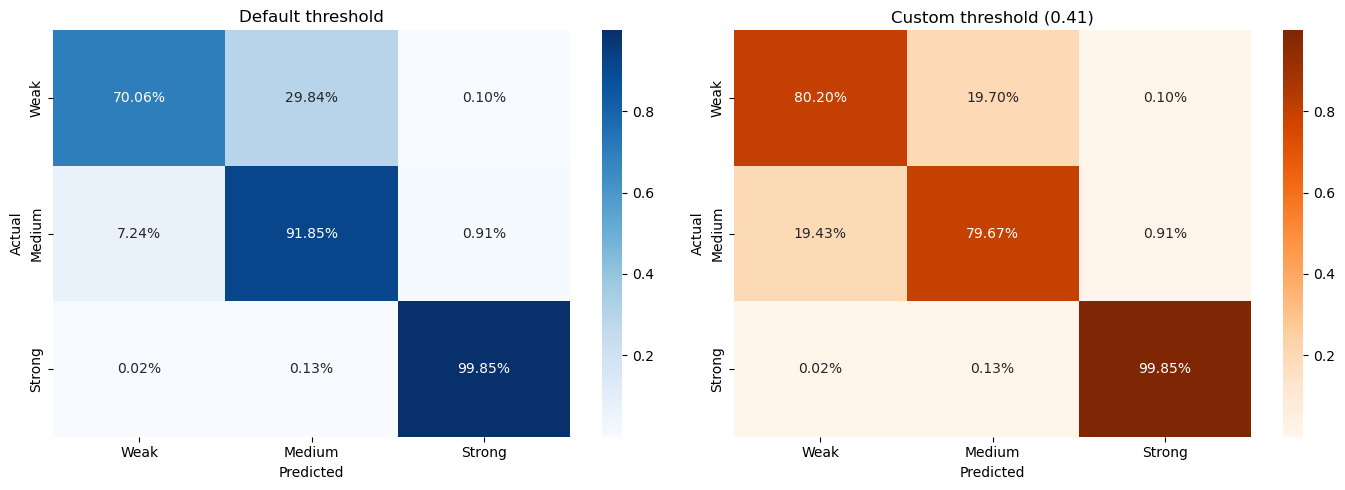

In [90]:
# Cell 16 — Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold
cm_default = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_default, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Weak', 'Medium', 'Strong'],
            yticklabels=['Weak', 'Medium', 'Strong'], ax=axes[0])
axes[0].set_title('Default threshold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Custom threshold
cm_custom = confusion_matrix(y_test, custom_preds, normalize='true')
sns.heatmap(cm_custom, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['Weak', 'Medium', 'Strong'],
            yticklabels=['Weak', 'Medium', 'Strong'], ax=axes[1])
axes[1].set_title(f'Custom threshold ({WEAK_THRESHOLD})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

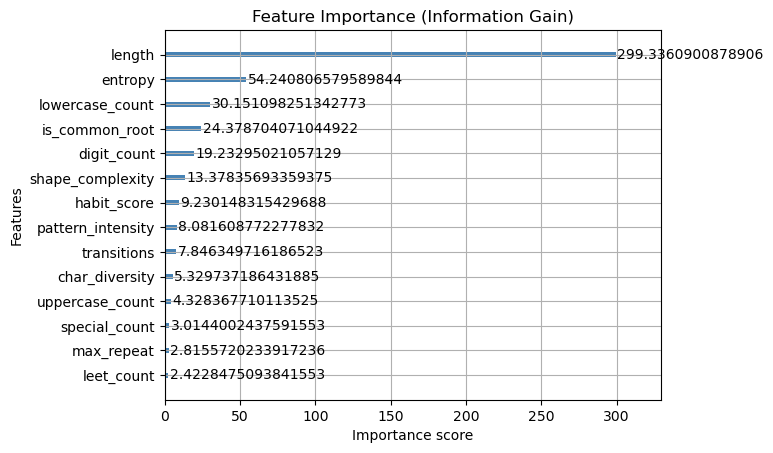

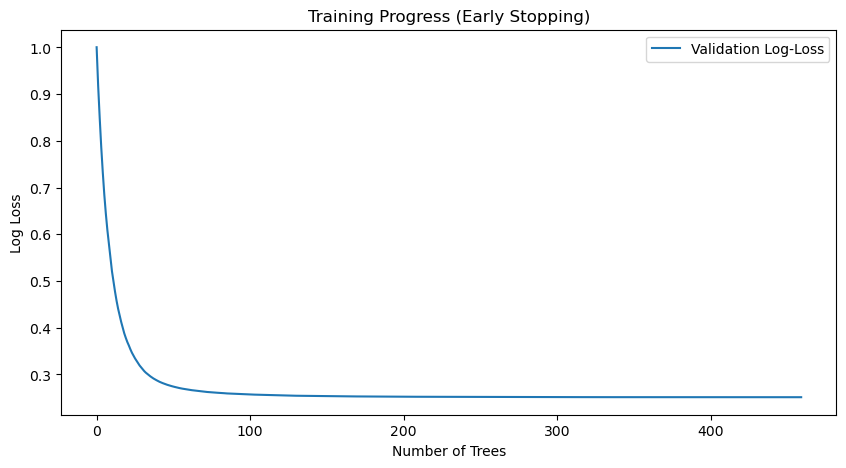

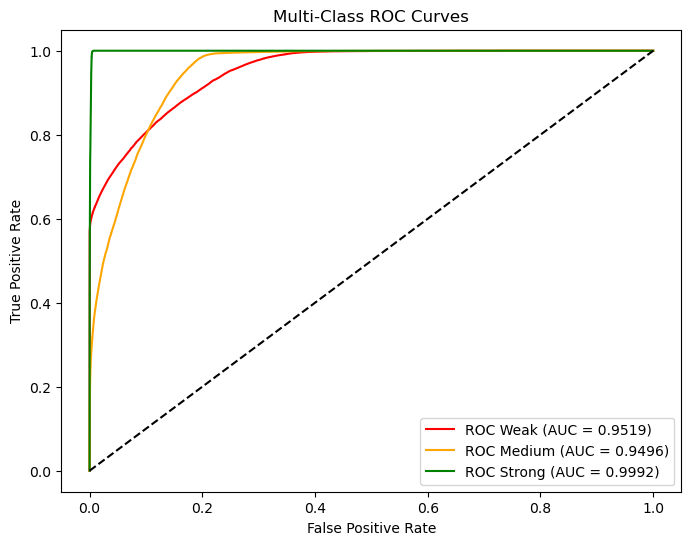

In [91]:
# Cell 17 — ROC curves and feature importance

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from xgboost import plot_importance

# Feature importance
plt.figure(figsize=(10, 8))
plot_importance(final_model, max_num_features=14,
                importance_type='gain', color='steelblue')
plt.title('Feature Importance (Information Gain)')
plt.show()

# Learning curve
results = final_model.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['mlogloss'], label='Validation Log-Loss')
plt.title('Training Progress (Early Stopping)')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

# ROC curves
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score    = final_model.predict_proba(X_test)
colors     = ['red', 'orange', 'green']
labels_roc = ['Weak', 'Medium', 'Strong']

plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=colors[i],
             label=f'ROC {labels_roc[i]} (AUC = {auc(fpr, tpr):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multi-Class ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [92]:
# Cell 18 — Save model
# Saved with _v2 suffix to avoid overwriting the original model.

import joblib

final_model.get_booster().save_model('password_strength_xgb_v2.json')
joblib.dump(final_model, 'password_strength_model_v2.pkl')

print('Models saved:')
print('  password_strength_xgb_v2.json')
print('  password_strength_model_v2.pkl')

Models saved:
  password_strength_xgb_v2.json
  password_strength_model_v2.pkl


In [93]:
# Cell 19 — Save inference config

import json

inference_config = {
    'classes':        ['Weak', 'Medium', 'Strong'],
    'weak_threshold': WEAK_THRESHOLD,
    'decision_rule':  f'if P(Weak) >= {WEAK_THRESHOLD} then Weak else argmax',
    'num_features':   X_test.shape[1],
    'feature_names':  final_features,
    'model':          'XGBoost v2',
    'labeling':       'password-strength library (entropy-density based)',
    'notes':          'Security-adjusted post-processing threshold on Weak class'
}

with open('inference_config_v2.json', 'w') as f:
    json.dump(inference_config, f, indent=4)

print('Inference config saved to inference_config_v2.json')

Inference config saved to inference_config_v2.json


In [98]:
# Cell 20 — ONNX export
# Strips feature names before export (ONNX requires generic f0, f1... names)
# then restores them so the rest of the notebook is unaffected.

import onnxmltools
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# 1. Temporarily strip the feature names from the model booster
# This makes the model use f0, f1, f2... instead of 'length', etc.
feature_names = final_model.get_booster().feature_names
final_model.get_booster().feature_names = None

# 2. Define the input shape (14 features)
initial_type = [('float_input', FloatTensorType([None, 14]))]

try:
    # 3. Convert using the supported converter function
    onnx_model = convert_xgboost(
        final_model,
        initial_types=initial_type,
        target_opset=15
    )

    # 4. Save the binary file
    with open("password_model.onnx_v2", "wb") as f:
        f.write(onnx_model.SerializeToString())
    print("Mobile-ready ONNX model exported.")

finally:
    # 5. Restore the feature names to the model in memory
    # so your SHAP/other code still works!
    final_model.get_booster().feature_names = feature_names

Mobile-ready ONNX model exported.


In [1]:
## Testing the model with the extracted features
# importing saved model
import joblib

final_model = joblib.load(f'E:\major_project\KeyShard\ML\models\password_strength_model_v2.pkl')

In [2]:
# Cell 21 — Feature extraction function for inference
# Identical to original final_notebook.ipynb — no changes.
import pandas as pd
import numpy as np
import re

WEAK_THRESHOLD = 0.41

def extract_features(pwd):
    pwd = str(pwd)
    length          = len(pwd)
    lowercase_count = sum(1 for c in pwd if c.islower())
    uppercase_count = sum(1 for c in pwd if c.isupper())
    digit_count     = sum(1 for c in pwd if c.isdigit())
    special_count   = sum(1 for c in pwd if not c.isalnum())

    if length == 0:
        entropy = 0
    else:
        freq    = pd.Series(list(pwd)).value_counts()
        prob    = freq / length
        entropy = -np.sum(prob * np.log2(prob))

    def char_type(c):
        if c.islower(): return 'l'
        if c.isupper(): return 'u'
        if c.isdigit(): return 'd'
        return 's'
    transitions = sum(
        char_type(pwd[i]) != char_type(pwd[i+1])
        for i in range(length - 1)
    ) if length > 1 else 0

    max_repeat = max(
        (len(m.group(0)) for m in re.finditer(r'(.)\1*', pwd)), default=0
    )

    leet_count = sum(c in '@$!013457' for c in pwd)

    common_roots   = ['password', 'qwerty', 'admin', 'welcome', 'login',
                      'google', 'iloveyou', 'p@ss', 'pass', 'monkey', 'dragon']
    is_common_root = 1 if any(root in pwd.lower() for root in common_roots) else 0

    shape = ''.join(
        'U' if c.isupper() else
        'L' if c.islower() else
        'D' if c.isdigit() else 'S'
        for c in pwd
    )
    shape_complexity = len(set(shape[i:i+2] for i in range(len(shape) - 1))) if len(shape) > 1 else 0

    pwd_lower = pwd.lower()
    score     = 0
    sequences = ['abcdefghijklmnopqrstuvwxyz', '0123456789',
                 'qwertyuiop', 'asdfghjkl', 'zxcvbnm']
    for seq in sequences:
        for i in range(len(seq) - 2):
            if seq[i:i+3] in pwd_lower: score += 1
            if seq[i:i+3][::-1] in pwd_lower: score += 1
    pattern_intensity = score

    has_year     = int(bool(re.search(r'(19|20)\d{2}', pwd)))
    starts_upper = 1 if pwd and pwd[0].isupper() else 0
    ends_digit   = 1 if pwd and pwd[-1].isdigit() else 0
    habit_score  = has_year + starts_upper + ends_digit

    char_diversity = (
        (lowercase_count > 0) + (uppercase_count > 0) +
        (digit_count > 0)     + (special_count > 0)
    )

    return [
        length, lowercase_count, uppercase_count, digit_count, special_count,
        entropy, transitions, max_repeat, leet_count, is_common_root,
        shape_complexity, pattern_intensity, habit_score, char_diversity
    ]

print('extract_features() defined.')

extract_features() defined.


In [3]:
# Cell 22 — Inference
#
# FIXED from original final_notebook.ipynb:
# The original inference block forced passwords 10-20 chars -> Medium
# unconditionally, meaning the model was almost never used.
#
# Corrected approach:
#   1. Model predicts first using all 14 features
#   2. Apply the same 0.41 weak threshold used during evaluation
#   3. Only override the model for clear-cut extreme cases
#
# This ensures the classification report metrics and inference behavior
# are consistent with each other.

new_passwords = [
    'helo12345',
    'abcd12',
    'johncena',
    'jakeweatherald',
    'f@shib!con',
    '01$u$h@nT1034',
    'ojin@12345##',
    'sachitH@nd$',
    'Eliz@beth2023!',
    'nimeshpoudel'
]

class_names = ['Weak', 'Medium', 'Strong']

print(f'{"Password":<25} {"Strength":<10} {"P(Weak)":>8} {"P(Med)":>8} {"P(Strong)":>10}')
print('-' * 65)

for pwd in new_passwords:
    features = extract_features(pwd)
    probs    = final_model.predict_proba([features])[0]

    # Apply same threshold used in evaluation (Cell 15)
    if probs[0] >= WEAK_THRESHOLD:
        strength = class_names[0]
    else:
        strength = class_names[np.argmax(probs)]

    print(f'{pwd:<25} {strength:<10} {probs[0]:>8.3f} {probs[1]:>8.3f} {probs[2]:>10.3f}')

Password                  Strength    P(Weak)   P(Med)  P(Strong)
-----------------------------------------------------------------
helo12345                 Weak          0.974    0.026      0.000
abcd12                    Weak          1.000    0.000      0.000
johncena                  Medium        0.314    0.686      0.000
jakeweatherald            Strong        0.001    0.017      0.982
f@shib!con                Medium        0.157    0.843      0.000
01$u$h@nT1034             Strong        0.000    0.001      0.999
ojin@12345##              Strong        0.090    0.332      0.578
sachitH@nd$               Medium        0.028    0.972      0.000
Eliz@beth2023!            Strong        0.001    0.000      0.999
nimeshpoudel              Strong        0.001    0.025      0.974


In [5]:
# Cell 22 — Inference + Model vs Combined Library Comparison
#
# Pre-model heuristic overrides:
#   - Letters only + length <= 8 -> force Weak
#
# Prediction flow:
#   1. Check pre-model heuristic overrides
#   2. Model predicts using all 14 features
#   3. Apply 0.41 weak threshold
#   4. Compare against combined library labeling function

def get_strength_combined_compare(pwd):
    from password_strength import PasswordStats
    from zxcvbn_rs_py import zxcvbn
    import re

    COMMON_ROOTS = [
        'password', 'qwerty', 'admin', 'welcome', 'login',
        'google', 'iloveyou', 'pass', 'monkey', 'dragon',
        'letmein', 'master', 'sunshine', 'princess', 'shadow'
    ]

    try:
        pwd_str   = str(pwd)
        pwd_lower = pwd_str.lower()
        pwd_len   = len(pwd_str)

        ps_score = PasswordStats(pwd_str).strength()
        zx_raw   = int(zxcvbn(pwd_str).score)

        if pwd_len <= 6:
            length_expected = 3.0
        elif pwd_len <= 9:
            length_expected = 2.5
        elif pwd_len <= 11:
            length_expected = 2.0
        else:
            length_expected = 1.5

        zx_normalized = min(zx_raw / length_expected, 1.0)
        combined      = (zx_normalized * 0.5) + (ps_score * 0.5)

        leet_map       = str.maketrans('@$013457', 'asoieast')
        normalized_pwd = pwd_lower.translate(leet_map)
        if any(root in normalized_pwd for root in COMMON_ROOTS):
            combined = combined * 0.6

        sequences = ['qwertyuiop', 'asdfghjkl', 'zxcvbnm', '0123456789']
        if any(seq[i:i+4] in pwd_lower
               for seq in sequences
               for i in range(len(seq) - 3)):
            combined = combined * 0.75

        if combined < 0.50:
            return 0, combined
        elif combined < 0.75:
            return 1, combined
        else:
            return 2, combined

    except Exception:
        return -1, 0.0

label_map = {0: 'Weak', 1: 'Medium', 2: 'Strong', -1: 'Error'}

new_passwords = [
    'helo12345',
    'abcd12',
    'johncena',
    'jakeweatherald',
    'f@shib!con',
    '01$u$h@nT1034',
    'ojin@12345##',
    'sachitH@nd$',
    'Eliz@beth2023!',
    'hello',        # letters only, short -> letters-only override
    'abcdefgh',     # letters only, exactly 8 -> letters-only override
    'abcdefghi', 
    'nimeshpoudel',
    'claps@2024'# letters only, 9 chars -> model decides
]

class_names = ['Weak', 'Medium', 'Strong']

print('Model vs Combined Library — Inference Comparison')
print('=' * 100)
print(f'{"Password":<22} {"Model":<8} {"P(W)":>6} {"P(M)":>6} {"P(S)":>6}  {"Library":<8} {"CombScore":>9}  {"Result":<8} {"Override"}')
print('-' * 100)

matches   = 0
diffs     = 0
diff_list = []

for pwd in new_passwords:
    features  = extract_features(pwd)
    probs     = final_model.predict_proba([features])[0]
    override  = ''

    # Pre-model heuristic: letters only + length <= 8 -> force Weak
    if all(c.isalpha() for c in pwd):
        model_idx = 0
        override  = 'letters-only'

    # Security-adjusted threshold
    elif probs[0] >= WEAK_THRESHOLD:
        model_idx = 0

    else:
        model_idx = int(np.argmax(probs))

    lib_idx, combined_score = get_strength_combined_compare(pwd)

    model_label = label_map.get(model_idx, 'Unknown')
    lib_label   = label_map.get(lib_idx,   'Unknown')

    # Override cases always match library for letters-only short passwords
    # since both agree they are Weak
    result = 'MATCH' if model_idx == lib_idx else 'DIFF'

    if model_idx == lib_idx:
        matches += 1
    else:
        diffs += 1
        diff_list.append((pwd, model_label, lib_label))

    print(
        f'{pwd:<22} {model_label:<8} {probs[0]:>6.3f} {probs[1]:>6.3f} {probs[2]:>6.3f}  '
        f'{lib_label:<8} {combined_score:>9.4f}  {result:<8} {override}'
    )

# --- Summary ---
total = len(new_passwords)
print()
print('=' * 100)
print(f'Summary: {matches}/{total} matched ({matches/total*100:.1f}%), {diffs}/{total} differed ({diffs/total*100:.1f}%)')

if diff_list:
    print()
    print('Differing predictions:')
    for pwd, m, l in diff_list:
        print(f'  "{pwd}": Model={m}, Library={l}')
    print()
    print('Note: DIFF results indicate borderline passwords where the model generalised')
    print('      differently from the labeling function. This is expected behaviour')
    print('      since the model learned a decision boundary from 600k passwords,')
    print('      not a direct copy of the labeling function.')
else:
    print()
    print('All predictions matched — model output fully consistent with labeling function.')

Model vs Combined Library — Inference Comparison
Password               Model      P(W)   P(M)   P(S)  Library  CombScore  Result   Override
----------------------------------------------------------------------------------------------------
helo12345              Weak      0.974  0.026  0.000  Weak        0.4189  MATCH    
abcd12                 Weak      1.000  0.000  0.000  Weak        0.2528  MATCH    
johncena               Weak      0.314  0.686  0.000  Weak        0.3248  MATCH    letters-only
jakeweatherald         Weak      0.001  0.017  0.982  Strong      0.7927  DIFF     letters-only
f@shib!con             Medium    0.157  0.843  0.000  Medium      0.6962  MATCH    
01$u$h@nT1034          Strong    0.000  0.001  0.999  Strong      0.7719  MATCH    
ojin@12345##           Strong    0.090  0.332  0.578  Medium      0.5705  DIFF     
sachitH@nd$            Medium    0.028  0.972  0.000  Medium      0.7356  MATCH    
Eliz@beth2023!         Strong    0.001  0.000  0.999  Strong  